# Football Data Mining Project
## CRISP-DM Based End-to-End Analysis

## 1. Business Understanding
This project analyzes football player statistics using data mining techniques including clustering, classification, regression, and PCA.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.decomposition import PCA


## 2. Data Understanding

In [18]:
# Load dataset
df = pd.read_csv(
    '2022-2023 Football Player Stats.csv',
    sep=';',
    encoding='latin-1'
)

print(df.shape)
df.head()


(2689, 124)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


In [19]:
# Dataset information
print(df.info())

# Missing values
print(df.isnull().sum())

# Statistical summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2689 entries, 0 to 2688
Columns: 124 entries, Rk to AerWon%
dtypes: float64(112), int64(7), object(5)
memory usage: 2.5+ MB
None
Rk         0
Player     0
Nation     1
Pos        0
Squad      0
          ..
OG         0
Recov      0
AerWon     0
AerLost    0
AerWon%    0
Length: 124, dtype: int64


,Rk,Age,Born,MP,Starts,Min,90s,Goals,Shots,SoT,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
count,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,...,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000,2689.000000
mean,1345.000000,26.011157,1996.155820,11.833023,8.476013,760.451097,8.450465,1.027520,1.245787,0.411261,...,0.204697,1.661636,0.990569,0.009249,0.015173,0.003142,4.951967,1.312064,1.497356,43.583600
std,776.391761,4.446259,4.450108,6.864278,6.994383,591.094260,6.567484,2.013714,1.424619,0.754716,...,0.552376,2.319000,1.235965,0.043781,0.077399,0.022607,2.901833,1.579539,1.830391,26.673092
min,1.000000,15.000000,1981.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,673.000000,23.000000,1993.000000,5.000000,2.000000,194.000000,2.200000,0.000000,0.260000,0.000000,...,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,3.330000,0.330000,0.550000,27.600000
50%,1345.000000,26.000000,1996.000000,13.000000,7.000000,684.000000,7.600000,0.000000,0.860000,0.180000,...,0.000000,0.760000,0.830000,0.000000,0.000000,0.000000,5.000000,0.930000,1.100000,46.400000
75%,2017.000000,29.000000,2000.000000,18.000000,14.000000,1245.000000,13.800000,1.000000,1.850000,0.590000,...,0.210000,2.500000,1.320000,0.000000,0.000000,0.000000,6.270000,1.790000,1.830000,60.000000
max,2689.000000,41.000000,2007.000000,23.000000,23.000000,2070.000000,23.000000,25.000000,15.000000,10.000000,...,10.000000,30.000000,20.000000,0.870000,2.000000,0.500000,30.000000,25.000000,30.000000,100.000000


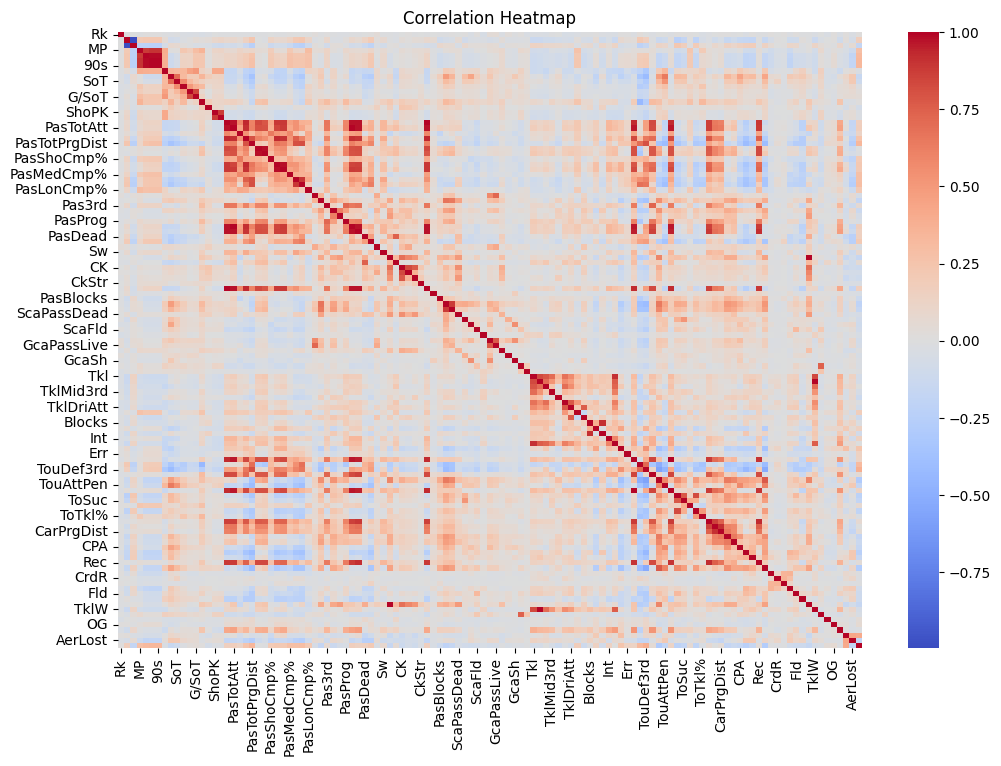

In [20]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 3. Data Preparation

In [21]:
# Remove players with low minutes
df = df[df['Min'] > 300].copy()

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Create simplified position column
df = df.assign(Main_Pos=df['Pos'].str[:2])

# Select features
drop_cols = ['Rk', 'Player', 'Nation', 'Squad', 'Comp', 'Born', 'Pos']
X_full = df.drop(columns=drop_cols, errors='ignore')

features = X_full.select_dtypes(include=[np.number]).drop(
    columns=['Goals', 'G/Sh', 'G/SoT', 'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib', 'GcaSh', 'GcaFld', 'GcaDef'],
    errors='ignore'
).columns.tolist()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print(X_scaled_df.shape)


(1830, 107)


## 4. Modeling
### 4.1 PCA

In [22]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

print('Explained Variance Ratio:')
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.22458073 0.18861291]


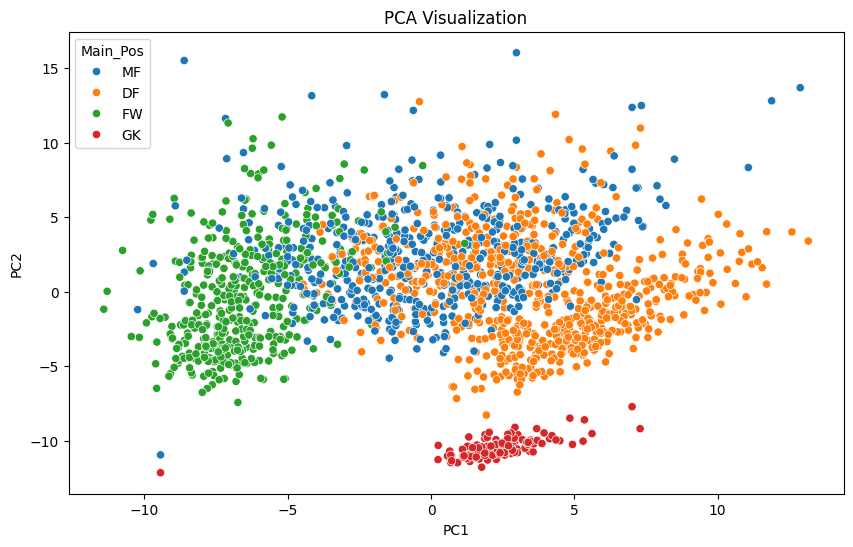

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['PC1'],
    y=df['PC2'],
    hue=df['Main_Pos']
)

plt.title('PCA Visualization')
plt.show()


### 4.2 Clustering

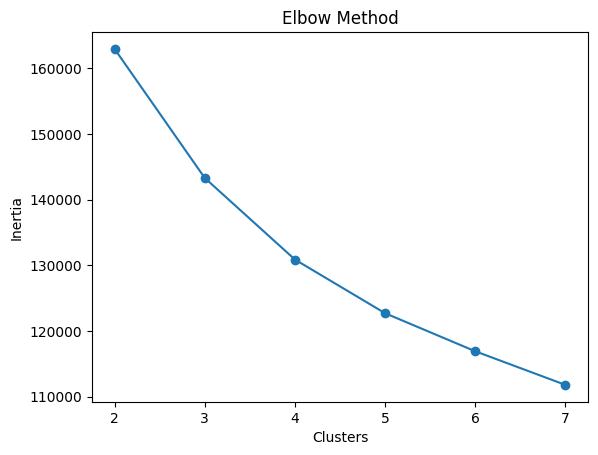

In [24]:
# Elbow Method
inertia = []

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [25]:
# Final KMeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

score = silhouette_score(X_scaled, df['Cluster'])

print('Silhouette Score:', score)


Cluster
3    585
0    572
1    546
2    127
Name: count, dtype: int64
Silhouette Score: 0.1640677020800632


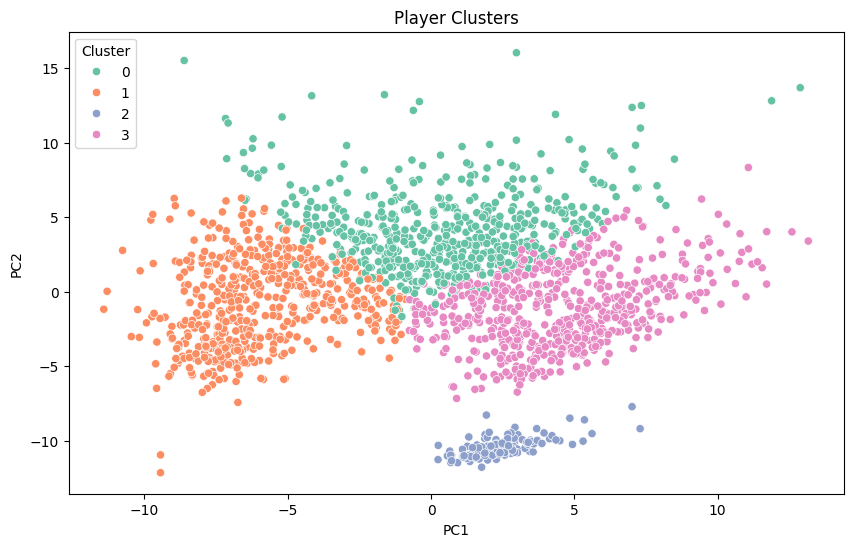

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['PC1'],
    y=df['PC2'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title('Player Clusters')
plt.show()


### 4.3 Classification

In [27]:
# Create classification target
median_goals = df['Goals'].median()

df['Scorer_Class'] = np.where(
    df['Goals'] >= median_goals,
    'High Scorer',
    'Low Scorer'
)

X_clf = X_scaled_df
y_clf = df['Scorer_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [28]:
print('Accuracy:', accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


Accuracy: 0.8451730418943534
              precision    recall  f1-score   support

 High Scorer       0.87      0.83      0.85       291
  Low Scorer       0.82      0.86      0.84       258

    accuracy                           0.85       549
   macro avg       0.85      0.85      0.85       549
weighted avg       0.85      0.85      0.85       549



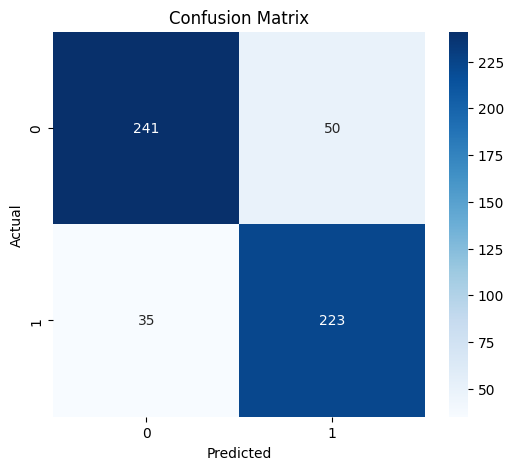

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


### 4.4 Regression

In [30]:
X_reg = df[['SCA', 'Shots', 'SoT']]
y_reg = df['Goals']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42
)

reg = LinearRegression()

reg.fit(X_train_r, y_train_r)

y_pred_r = reg.predict(X_test_r)


In [31]:
print('R2 Score:', r2_score(y_test_r, y_pred_r))

print('MSE:', mean_squared_error(y_test_r, y_pred_r))

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print('RMSE:', rmse)


R2 Score: 0.4967165276146136
MSE: 2.178589034497197
RMSE: 1.476004415473476


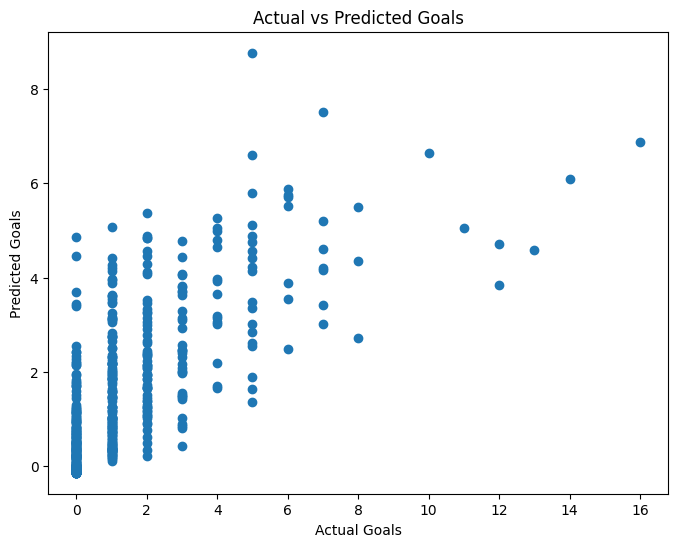

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_r, y_pred_r)

plt.xlabel('Actual Goals')
plt.ylabel('Predicted Goals')

plt.title('Actual vs Predicted Goals')

plt.show()


## 5. Evaluation & Business Insights

### Key Findings
- PCA reduced dimensionality and revealed player structure.
- Clustering identified different player groups.
- Classification successfully separated high and low scorers.
- Regression estimated goals based on attacking metrics.


## 6. Deployment
The deployment layer of this project is an interactive Streamlit dashboard containing:
- PCA visualizations
- Cluster analysis
- Classification results
- Regression charts
- Business insights panel
